<a href="https://colab.research.google.com/github/IssarapongB/Data-science/blob/main/99424_LAB_ACTIVITY2_DAY2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1306]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("Ready for Reinforcement Learning Lab 2: Q-Learning")

Ready for Reinforcement Learning Lab 2: Q-Learning


In [1307]:
N = 4
START = 0
GOAL = 15
HOLES = {5, 7, 11, 12}
ACTIONS = {0: "Left", 1: "Down", 2: "Right", 3: "Up"} # 0=ซ้าย 1=ลง 2=ขวา 3=ขึ้น

print("Grid size:", N, "x", N)
print("Start:", START)
print("Goal:", GOAL)
print("Holes:", HOLES)
print("Actions:", ACTIONS)

Grid size: 4 x 4
Start: 0
Goal: 15
Holes: {11, 12, 5, 7}
Actions: {0: 'Left', 1: 'Down', 2: 'Right', 3: 'Up'}


In [1308]:
# Convert State to Row/Column
def to_rc(state):
    row = state // N   # หารเอาส่วน = แถว
    col = state % N    # หารเอาเศษ = คอลัมน์
    return row, col

def to_state(row, col):
    state = row * N + col
    return state

def move(state, action):
    row, col = to_rc(state)
    if action == 0:    col = max(0, col - 1)      # ซ้าย
    elif action == 1:  row = min(N-1, row + 1)    # ลง
    elif action == 2:  col = min(N-1, col + 1)    # ขวา
    elif action == 3:  row = max(0, row - 1)      # ขึ้น
    return to_state(row, col)

In [1309]:
def step_env(state, action):
    new_state = move(state, action)
    if new_state in HOLES: # แก้ไขจาก new state เป็น new_state
        reward = -1
        done = True
    elif new_state == GOAL:
        reward = 1
        done = True
    else:
        reward = 0
        done = False
    return new_state, reward, done

In [1310]:
def plot_grid(path=None, title="Grid World"):
    fig, ax = plt.subplots(figsize=(5, 5))
    for r in range(N):
        for c in range(N):
            state = to_state(r, c)
            rect = patches.Rectangle((c, r), 1, 1, fill=False, linewidth=1.5)
            ax.add_patch(rect)

            if state == START:
                label = "S\n0"
            elif state == GOAL:
                label = "G\n15"
            elif state in HOLES:
                label = "H\n" + str(state)
            else:
                label = str(state)

            ax.text(
                c + 0.5,
                r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=13
            )

    if path is not None:
        xs = []
        ys = []
        for s in path:
            r, c = to_rc(s)
            xs.append(c + 0.5)
            ys.append(r + 0.5)
        ax.plot(xs, ys, marker="o", linewidth=2, color="orange")

    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.show()

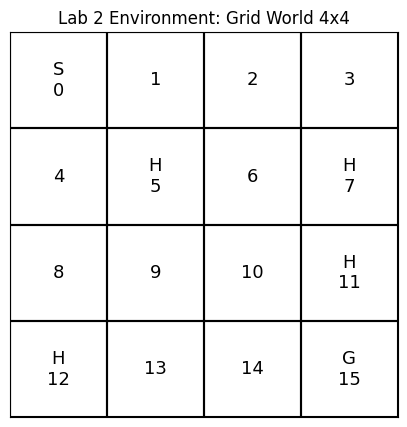

In [1311]:
plot_grid(title="Lab 2 Environment: Grid World 4x4")

In [1312]:
n_states  = N * N   # 16 states
n_actions = 4
Q = np.zeros((n_states, n_actions))   # ตาราง 16×4 เริ่มที่ 0 ทั้งหมด

print("Q-table shape:", Q.shape)      #  →  (16, 4)

Q-table shape: (16, 4)


In [1313]:
def choose_action(state, epsilon):
    if np.random.rand() < epsilon:
        action = np.random.randint(0, n_actions)  		# สำรวจ (สุ่ม)
    else:
        action = np.argmax(Q[state])              			# ใช้ความรู้
    return int(action)

# def choose_action(state, epsilon):
#     if np.random.rand() < epsilon:
#         # สำรวจ (สุ่ม) เลือกจากทุกทิศทางที่เป็นไปได้
#         action = np.random.randint(0, n_actions)
#     else:
#         # ใช้ความรู้ (แบบสุ่มกระจายตัวเมื่อคะแนนสูงสุดเท่ากัน)
#         max_value = np.max(Q[state])
#         max_indices = np.where(Q[state] == max_value)[0]
#         action = np.random.choice(max_indices)

#     return int(action)


In [1314]:
state = 0
for epsilon in [1.0, 0.5, 0.1, 0.0]:
    print("epsilon =", epsilon)
    actions = []
    for i in range(20):
        action = choose_action(state, epsilon)
        actions.append(action)
    print(actions)
    print()

epsilon = 1.0
[0, 0, 3, 1, 2, 3, 0, 1, 1, 2, 2, 3, 2, 2, 2, 2, 3, 3, 1, 3]

epsilon = 0.5
[0, 1, 0, 3, 0, 0, 2, 0, 3, 0, 2, 0, 0, 0, 3, 0, 0, 2, 0, 0]

epsilon = 0.1
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

epsilon = 0.0
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]



In [1315]:
alpha         = 0.1      # อัตราเรียนรู้
gamma         = 0.95     # ให้ความสำคัญอนาคต
epsilon       = 1.0      # เริ่มสุ่มทั้งหมด
epsilon_min   = 0.05     # ต่ำสุด
epsilon_decay = 0.995    # ลดช้า ๆ ทุก Episode
episodes      = 10000     # จำนวนรอบฝึก
max_steps     = 100      # steps สูงสุด/episode
success_flags = []       # เก็บผลสำเร็จ

In [1316]:
for ep in range(episodes):
    state = START
    win   = 0
    for step in range(max_steps):
        action = choose_action(state, epsilon)
        new_state, reward, done = step_env(state, action)

        # ─── อัปเดต Q-table ───
        old_value = Q[state, action]
        next_max  = np.max(Q[new_state])
        Q[state, action] = old_value + alpha * (reward + gamma * next_max - old_value)

        state = new_state
        if done:
            if state == GOAL:
                win = 1
            break

    success_flags.append(win)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)  # ลด epsilon ทีละน้อย

print("Training finished")
print("Final epsilon:", epsilon)
print("Success rate:", np.mean(success_flags) * 100)

Training finished
Final epsilon: 0.05
Success rate: 92.55


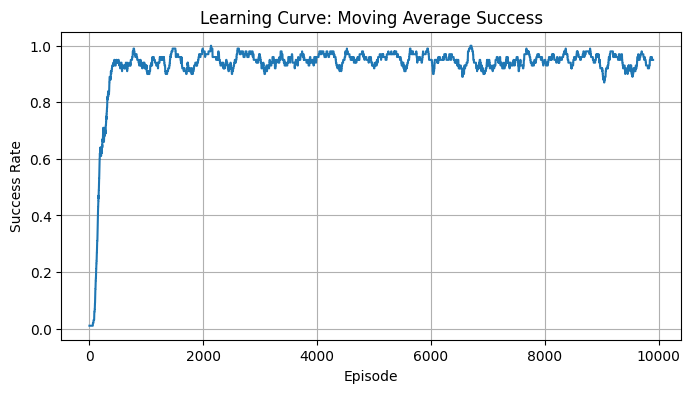

In [1317]:
window = 100
moving_avg = np.convolve(success_flags, np.ones(window)/window, mode="valid")

plt.figure(figsize=(8, 4))
plt.plot(moving_avg) # แก้ไขจาก moving_average เป็น moving_avg ให้ตรงกับตัวแปรที่ประกาศ
plt.title("Learning Curve: Moving Average Success")
plt.xlabel("Episode")
plt.ylabel("Success Rate")
plt.grid(True)
plt.show()

In [1318]:
arrow = {0: " ← ", 1: " ↓ ", 2: " → ", 3: " ↑ "}

for state in range(n_states):
    best_action = np.argmax(Q[state])
    print(f"State {state:2d}: Q={np.round(Q[state], 2)} Best={arrow[best_action]}")

State  0: Q=[0.74 0.77 0.7  0.74] Best= ↓ 
State  1: Q=[ 0.74 -0.99  0.01  0.13] Best= ← 
State  2: Q=[0.13 0.   0.   0.  ] Best= ← 
State  3: Q=[ 0.   -0.41  0.    0.  ] Best= ← 
State  4: Q=[ 0.77  0.81 -1.    0.74] Best= ↓ 
State  5: Q=[0. 0. 0. 0.] Best= ← 
State  6: Q=[-0.34  0.15 -0.1   0.  ] Best= ↓ 
State  7: Q=[0. 0. 0. 0.] Best= ← 
State  8: Q=[ 0.81 -1.    0.86  0.77] Best= → 
State  9: Q=[ 0.81  0.9   0.81 -1.  ] Best= ↓ 
State 10: Q=[ 0.86  0.44 -0.52  0.01] Best= ← 
State 11: Q=[0. 0. 0. 0.] Best= ← 
State 12: Q=[0. 0. 0. 0.] Best= ← 
State 13: Q=[-1.    0.9   0.95  0.86] Best= → 
State 14: Q=[0.9  0.95 1.   0.81] Best= → 
State 15: Q=[0. 0. 0. 0.] Best= ← 


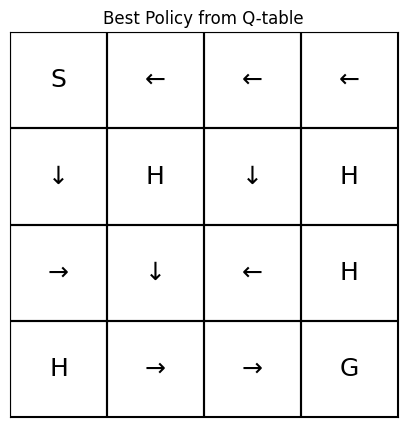

In [1319]:
def plot_policy():
    fig, ax = plt.subplots(figsize=(5, 5))
    for r in range(N):
        for c in range(N):
            state = to_state(r, c)
            rect = patches.Rectangle((c, r), 1, 1, fill=False, linewidth=1.5)
            ax.add_patch(rect)

            if state == START:
                label = "S"
            elif state == GOAL:
                label = "G"
            elif state in HOLES:
                label = "H"
            else:
                best_action = np.argmax(Q[state])
                label = arrow[best_action]

            ax.text(
                c + 0.5,
                r + 0.5,
                label,
                ha="center",
                va="center",
                fontsize=18
            )

    ax.set_xlim(0, N)
    ax.set_ylim(0, N)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Best Policy from Q-table")
    plt.show()

plot_policy()

Best path: [0, 4, 8, 9, 13, 14, 15]


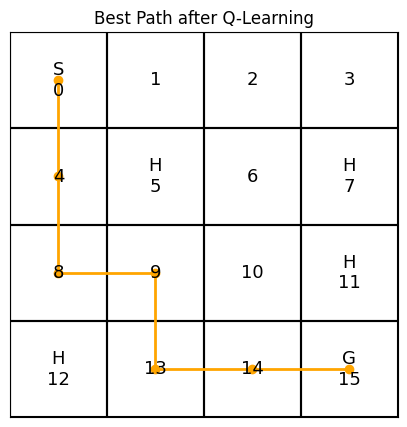

In [1320]:
state = START
path = [state]

for step in range(20):
    action = np.argmax(Q[state])   # epsilon=0 → ใช้ความรู้ล้วน ๆ ไม่สุ่มแล้ว
    new_state, reward, done = step_env(state, action)
    path.append(new_state)
    state = new_state
    if done:
        break

print("Best path:", path)
plot_grid(path, title="Best Path after Q-Learning")